# Z-Test
    A Z-Test is a statistical test used to determine whether a sample mean is significantly different from a known population mean.

    It uses the Standard Normal Distribution (Z-distribution) to calculate the probability of observing the sample result if the Null Hypothesis is true.

    Use a Z-Test when
        - The population standard deviation (σ) is known.
        - The sample size is at least 30(n>=30).
        - The sample is randomly selected.
        - The observations are independent.
        - The data follows a normal distribution or the sample size is large enough for the Central Limit Theorem to apply.
    
     The Z-Test measures how many Standard Errors the sample mean is away from the population mean.
     This quantity is called the Z-score or Z-statistic.


# Z-Test Formula
    The test statistic is calculated as

$$
Z=\frac{\bar{x}-\mu}{\sigma/\sqrt{n}}
$$

    where

- $\bar{x}$ = Sample Mean
- $\mu$ = Population Mean
- $\sigma$ = Population Standard Deviation
- $n$ = Sample Size

### Types of Z-Tests
    There are three common types of Z-Tests.

    One-Sample Z-Test
        Used to compare a sample mean with a known population mean.

    Two-Sample Z-Test
        Used to compare the means of two independent populations.

    Proportion Z-Test
        Used to compare proportions or percentages.



### Common critical values for α = 0.05

            Test Type     |    Critical Value
---
            Two-Tailed    |     ±1.96

            Right-Tailed  |     1.645

            Left-Tailed   |    -1.645

### (One-Sample)  State the Hypotheses

        Null Hypothesis

$$
H_0:\mu=60000
$$

        Alternative Hypothesis

$$
H_1:\mu\neq60000
$$

    This is a Two-Tailed Z-Test because we are checking whether the average salary is different from ₹60,000.

### Sample Information

                Population Mean

$$
\mu=60000
$$

                Sample Mean

$$
\bar{x}=58500
$$

                Population Standard Deviation

$$
\sigma=8000
$$

                Sample Size

$$
n=50
$$

                Significance Level

$$
\alpha=0.05
$$

In [22]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import scipy.stats as st
from scipy.stats import norm



In [6]:
population_mean = 60000

sample_mean = 58500

population_std = 8000

sample_size = 50

alpha = 0.05

### Calculate the Standard Error
    The Standard Error measures how much the sample mean is expected to vary from the population mean.

    Formula

$$
SE=\frac{\sigma}{\sqrt{n}}
$$

In [7]:
SE = population_std / np.sqrt(sample_size)

print(f"Standard Error : {SE:.2f}")

Standard Error : 1131.37


### Calculate the Z-Test Statistic
    The Z-Test Statistic measures how many Standard Errors the sample mean is away from the population mean.

    Formula

$$
Z=\frac{\bar{x}-\mu}{\sigma/\sqrt{n}}
$$

In [10]:
z = (sample_mean - population_mean) / SE

print(f"Z Statistic : {z:.2f}")

Z Statistic : -1.33


### Calculate the p-value
    The p-value represents the probability of observing a result at least as extreme as the sample result, assuming the Null Hypothesis is true.

    For a Two-Tailed Test,

$$
p=2\times P(Z\le z)
$$

In [15]:

p_value = 2 * norm.cdf(z)

print(f"p-value : {p_value:.4f}")

p-value : 0.1849


### Decision Rule

            If

$$
p\le\alpha
$$

                        Reject the Null Hypothesis.

            Otherwise,

                        Fail to Reject the Null Hypothesis.

In [16]:
if p_value <= alpha:

    print("Reject the Null Hypothesis")

else:

    print("Fail to Reject the Null Hypothesis")

Fail to Reject the Null Hypothesis


### Decision Making in a Z-Test
    After calculating the Z Statistic, the final decision can be made using one of two methods.
        1. Critical Value Approach
        2. p-value Approach


### Method 1: Critical Value Approach
    The Critical Value Approach compares the calculated Z Statistic with the Critical Z Value.

    If the calculated Z Statistic falls inside the Rejection Region,

        Reject the Null Hypothesis.

    Otherwise,

        Fail to Reject the Null Hypothesis.

### Critical Values
            For a 5% Significance Level

                    Two-Tailed Test

$$
Z=\pm1.96
$$

                    Right-Tailed Test

$$
Z=1.645
$$

                    Left-Tailed Test

$$
Z=-1.645
$$

### Example
        Our calculated Z Statistic is

$$
Z=-1.33
$$

        Critical Values are

$$
-1.96 \quad\text{and}\quad +1.96
$$

        Since

$$
-1.96<-1.33<1.96
$$

        the Z Statistic lies inside the Acceptance Region.

        Therefore,
            Fail to Reject the Null Hypothesis.

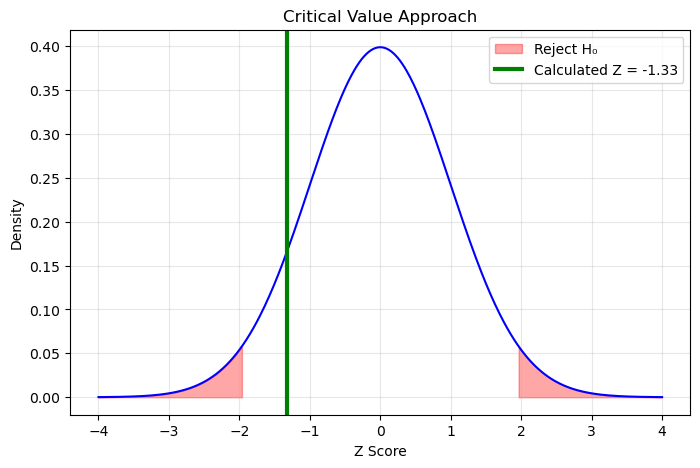

In [23]:

x = np.linspace(-4,4,500)

y = norm.pdf(x)

plt.figure(figsize=(8,5))

plt.plot(x,y,color="blue")

plt.fill_between(x,y, where=(x<=-1.96), color="red", alpha=0.35,label="Reject H₀")

plt.fill_between(x,y,where=(x>=1.96),color="red",alpha=0.35)

plt.axvline(z,color="green",linewidth=3,label=f"Calculated Z = {z:.2f}")

plt.title("Critical Value Approach")

plt.xlabel("Z Score")

plt.ylabel("Density")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Method 2: p-value Approach
    The p-value Approach compares the calculated p-value with the Significance Level.

    Decision Rule
        If

$$
p\le\alpha
$$
               
                Reject the Null Hypothesis.

        Otherwise,
                Fail to Reject the Null Hypothesis.

### Example
    Calculated p-value

$$
0.1841
$$

    Significance Level

$$
0.05
$$

    Since

$$
0.1841>0.05
$$

    Fail to Reject the Null Hypothesis.

In [24]:
print(f"p-value : {p_value:.4f}")

print(f"Alpha : {alpha}")

if p_value <= alpha:

    print("Reject H₀")

else:

    print("Fail to Reject H₀")

p-value : 0.1849
Alpha : 0.05
Fail to Reject H₀


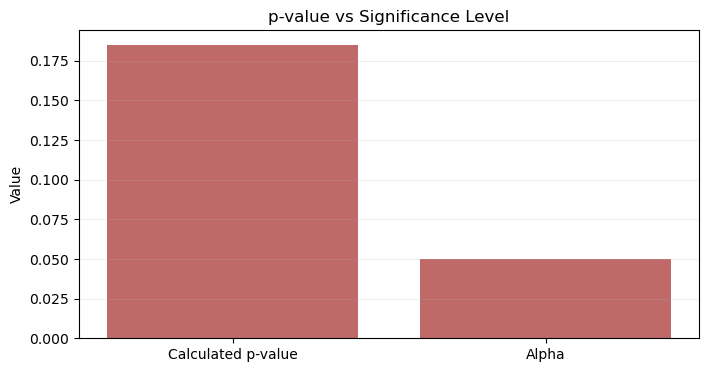

In [29]:
plt.figure(figsize=(8,4))

plt.bar(

    ["Calculated p-value","Alpha"],

    [p_value,alpha],
    color='brown',
    alpha=0.7
)

plt.title("p-value vs Significance Level")

plt.ylabel("Value")

plt.grid(axis="y",alpha=0.2)

plt.show()

### Limitations of the Z-Test
    - Requires the population standard deviation to be known.
    - Best suited for large sample sizes.
    - Not appropriate when the population standard deviation is unknown.
    - Assumes observations are independent.
    - Assumes the sampling distribution is approximately normal.